## Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the cleaned and aggregated transformer-level dataset.

Objectives:
- Understand the final dataset structure
- Analyze the distribution of the target variable
- Explore numerical and categorical features
- Compare features between Fault and Normal transformers
- Identify relationships, patterns, and potential outliers

In [30]:
# import necessary libs 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

In [31]:
# load the processed labeled dataset

labeled_data = pd.read_csv(
    "../data/processed_data/labeled_data.csv"
)

In [32]:
labeled_data.head()

,transformer_id,install_year,rated_kva,cooling_type,zone,gas_mean,gas_max,gas_std,oil_temp_mean,oil_temp_max,oil_temp_std,load_mean,load_max,load_std,fault_status
0,TXR-0001,2012,250,ONAF,Zone 3,143.895994,147.817787,3.216604,63.097518,67.064311,4.360108,94.450842,104.927908,8.915228,Fault
1,TXR-0002,2019,500,ONAN,Zone 3,100.991994,123.367978,15.073843,52.544203,65.398255,6.346153,65.642144,82.275383,8.850842,Fault
2,TXR-0003,2009,500,OFAF,Zone 1,103.183072,122.118616,17.408723,57.813396,67.197059,5.172855,71.619793,82.604979,10.675000,Fault
3,TXR-0004,2008,100,ONAF,Zone 1,125.595390,151.866470,19.034478,42.952912,49.972436,5.498816,50.071346,70.107299,9.690446,Normal
4,TXR-0005,2006,250,ONAN,Zone 2,115.326868,202.066251,43.176527,51.196584,53.452318,1.964975,64.048775,73.754073,8.496023,Normal


In [33]:
print("Shape:", labeled_data.shape)

Shape: (198, 15)


In [34]:
labeled_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transformer_id  198 non-null    object 
 1   install_year    198 non-null    int64  
 2   rated_kva       198 non-null    int64  
 3   cooling_type    198 non-null    object 
 4   zone            198 non-null    object 
 5   gas_mean        198 non-null    float64
 6   gas_max         198 non-null    float64
 7   gas_std         198 non-null    float64
 8   oil_temp_mean   198 non-null    float64
 9   oil_temp_max    198 non-null    float64
 10  oil_temp_std    198 non-null    float64
 11  load_mean       198 non-null    float64
 12  load_max        198 non-null    float64
 13  load_std        198 non-null    float64
 14  fault_status    198 non-null    object 
dtypes: float64(9), int64(2), object(4)
memory usage: 23.3+ KB


### 1. Target Variable Distribution

First, we examine the distribution of the target variable `fault_status` to understand the class balance in the labeled dataset.

In [35]:
labeled_data["fault_status"].value_counts()

Normal    149
Fault      49
Name: fault_status, dtype: int64

In [36]:
labeled_data["fault_status"].value_counts(normalize=True) * 100

Normal    75.252525
Fault     24.747475
Name: fault_status, dtype: float64

### 1.1 Visualizing Target Distribution

A bar chart helps visualize the class imbalance between Fault and Normal transformers.

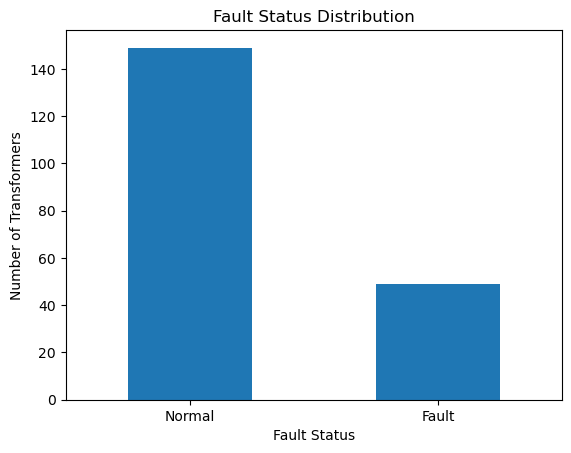

In [37]:
import matplotlib.pyplot as plt

labeled_data["fault_status"].value_counts().plot(kind="bar")

plt.title("Fault Status Distribution")
plt.xlabel("Fault Status")
plt.ylabel("Number of Transformers")
plt.xticks(rotation=0)
plt.show()

### 2. Numerical Feature Analysis

We examine the statistical properties of the numerical variables to understand their ranges, central tendency, spread, and potential outliers.

In [38]:
numeric_cols = labeled_data.select_dtypes(
    include=["int64", "float64"]
).columns

labeled_data[numeric_cols].describe()

,install_year,rated_kva,gas_mean,gas_max,gas_std,oil_temp_mean,oil_temp_max,oil_temp_std,load_mean,load_max,load_std
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,2010.191919,425.505051,90.316848,125.265622,20.388274,54.872440,61.661205,4.898133,69.835933,81.591433,7.887656
std,7.102122,331.422863,41.774074,71.561777,20.760606,6.646733,7.540258,1.582379,13.098064,13.524512,2.238489
min,1998.000000,100.000000,4.400552,12.985270,2.745290,33.486368,37.211849,0.851793,27.598779,39.203596,2.330841
25%,2004.250000,100.000000,62.424633,78.981259,11.081297,50.663317,56.442485,3.987424,60.790936,71.963853,6.492373
50%,2011.000000,250.000000,90.772184,112.277563,14.929036,55.180259,61.930658,4.856179,71.330231,82.234323,7.619576
75%,2016.000000,500.000000,116.251715,147.291018,18.852921,59.496361,66.838051,5.863408,79.900343,91.027788,9.335763
max,2022.000000,1000.000000,202.740286,443.450958,122.953885,71.622075,82.630619,10.310332,99.866420,112.334312,17.714733


### 2.1 Distribution of Numerical Features

Histograms are used to understand the distribution of each numerical variable and identify skewness or potential outliers.

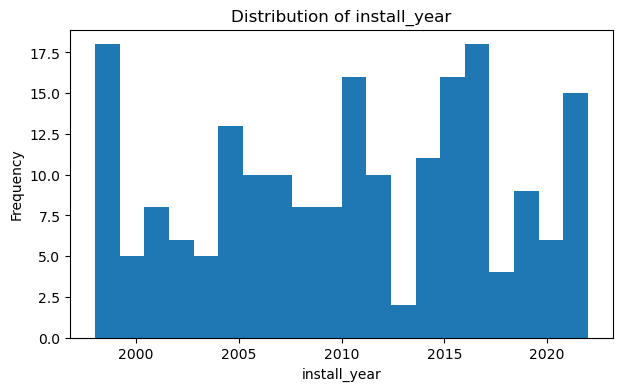

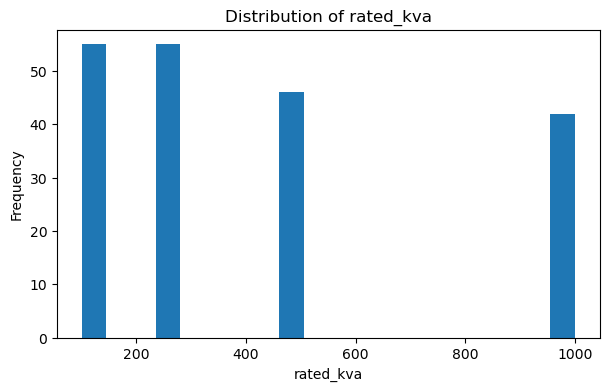

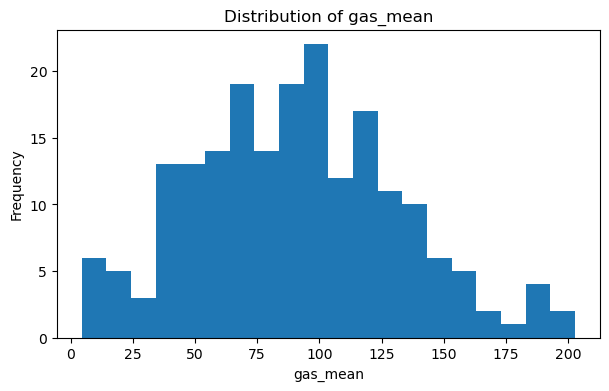

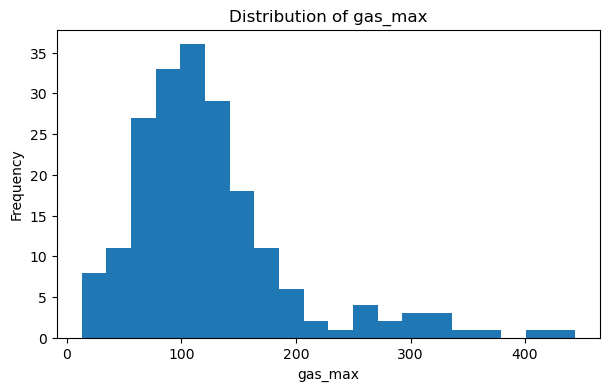

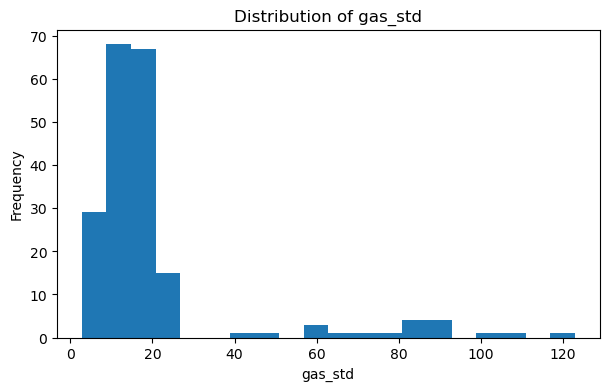

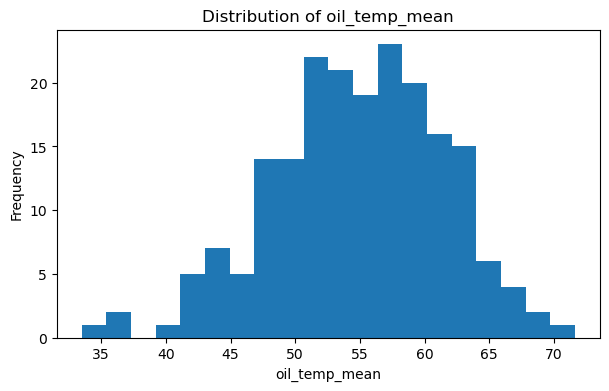

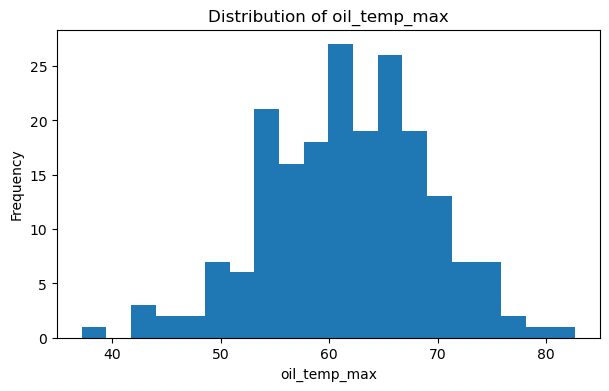

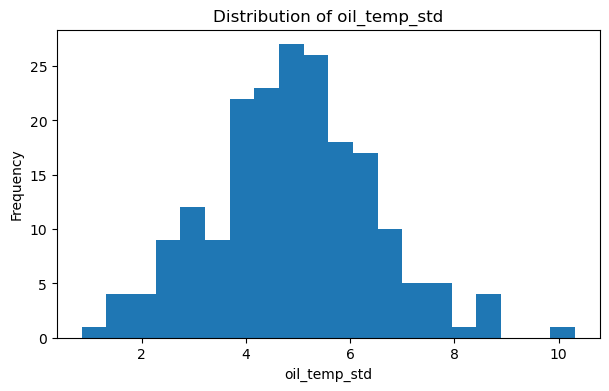

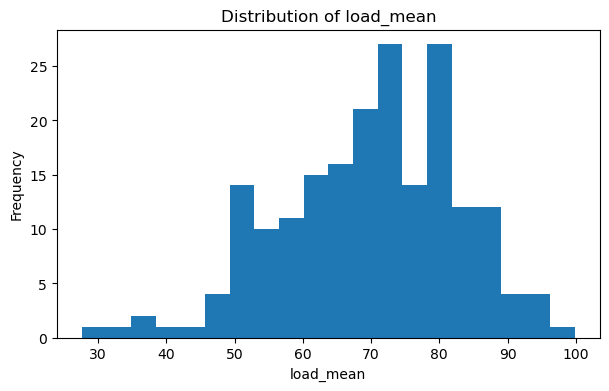

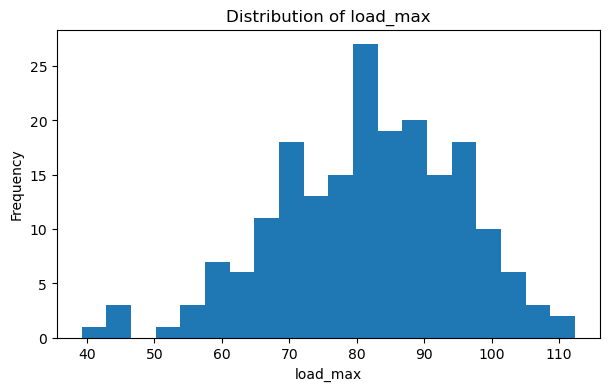

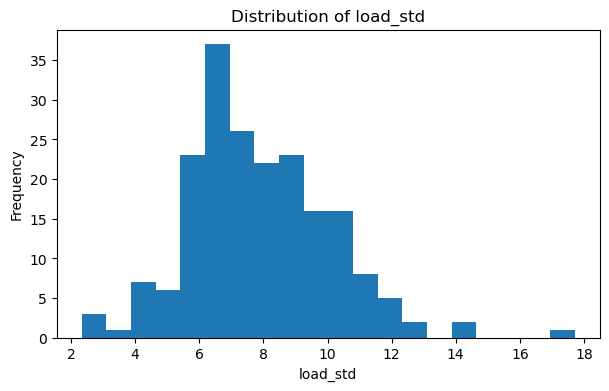

In [39]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(labeled_data[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### 2.2 Checking Feature Skewness

The skewness statistic is used to quantify the asymmetry observed in the numerical feature distributions.

In [40]:
skewness = labeled_data[numeric_cols].skew().sort_values()

skewness

load_mean       -0.461392
load_max        -0.406725
oil_temp_mean   -0.311152
oil_temp_max    -0.225968
install_year    -0.112807
oil_temp_std     0.209459
gas_mean         0.252654
load_std         0.627415
rated_kva        0.815369
gas_max          1.729851
gas_std          2.949427
dtype: float64

### 3. Categorical Feature Analysis

We examine the distribution of categorical variables to understand how transformers are distributed across cooling types and zones.

In [41]:
categorical_cols = labeled_data.select_dtypes(
    include=["object"]
).columns

categorical_cols

Index(['transformer_id', 'cooling_type', 'zone', 'fault_status'], dtype='object')

In [42]:
categorical_features = [
    "cooling_type",
    "zone"
]

In [43]:
for col in categorical_features:
    print(f"\n{col}")
    print(labeled_data[col].value_counts())


cooling_type
ONAN       66
ONAF       65
OFAF       61
Unknown     6
Name: cooling_type, dtype: int64

zone
Zone 1    67
Zone 2    67
Zone 3    64
Name: zone, dtype: int64


### 3.1 Distribution of Categorical Features

Bar charts are used to visualize the number of transformers in each category.

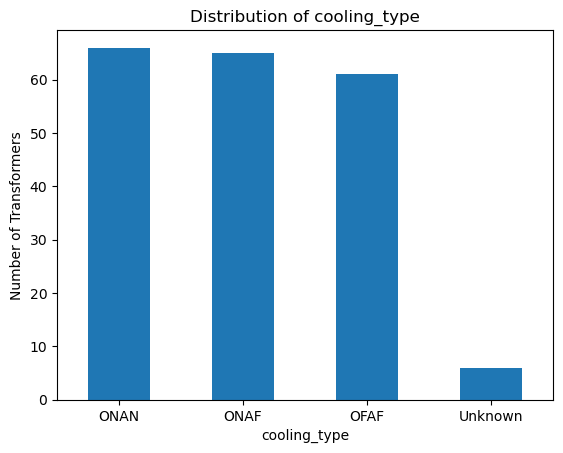

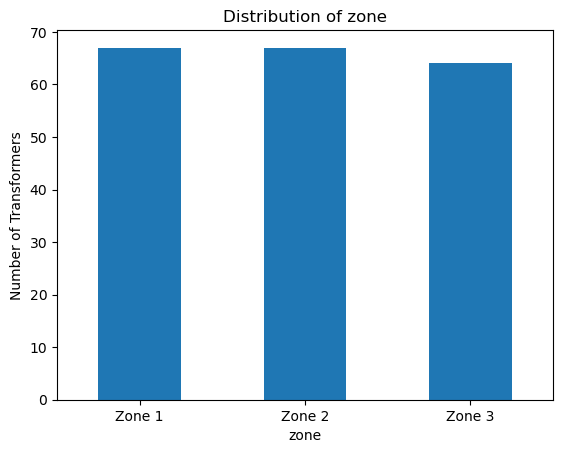

In [44]:
for col in categorical_features:
    labeled_data[col].value_counts().plot(kind="bar")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Transformers")
    plt.xticks(rotation=0)
    plt.show()

### 3.2 Fault Distribution Across Categorical Features

We compare the target distribution across categorical features to identify whether certain categories appear more frequently among Fault transformers.

In [45]:
pd.crosstab(
    labeled_data["cooling_type"],
    labeled_data["fault_status"]
)

fault_status,Fault,Normal
cooling_type,,
OFAF,19,42
ONAF,15,50
ONAN,13,53
Unknown,2,4


In [46]:
pd.crosstab(
    labeled_data["zone"],
    labeled_data["fault_status"]
)

fault_status,Fault,Normal
zone,,
Zone 1,17,50
Zone 2,14,53
Zone 3,18,46


In [47]:
pd.crosstab(
    labeled_data["cooling_type"],
    labeled_data["fault_status"],
    normalize="index" 
)

fault_status,Fault,Normal
cooling_type,,
OFAF,0.311475,0.688525
ONAF,0.230769,0.769231
ONAN,0.196970,0.803030
Unknown,0.333333,0.666667


In [48]:
pd.crosstab(
    labeled_data["zone"],
    labeled_data["fault_status"],
    normalize="index"
)

fault_status,Fault,Normal
zone,,
Zone 1,0.253731,0.746269
Zone 2,0.208955,0.791045
Zone 3,0.281250,0.718750


### 3.3 Numerical Features vs Fault Status

We compare the numerical feature distributions between Fault and Normal transformers to identify potential relationships between transformer operating characteristics and fault status.

In [49]:
numeric_cols = labeled_data.select_dtypes(
    include=["int64", "float64"]
).columns

labeled_data.groupby("fault_status")[numeric_cols].mean()

,install_year,rated_kva,gas_mean,gas_max,gas_std,oil_temp_mean,oil_temp_max,oil_temp_std,load_mean,load_max,load_std
fault_status,,,,,,,,,,,
Fault,2010.877551,429.591837,116.351007,165.630423,25.020738,57.144036,64.060740,4.879924,73.883913,84.683527,7.512878
Normal,2009.966443,424.161074,81.755279,111.991291,18.864846,54.125405,60.872096,4.904121,68.504718,80.574570,8.010905


In [50]:
labeled_data.groupby("fault_status")[numeric_cols].median()

,install_year,rated_kva,gas_mean,gas_max,gas_std,oil_temp_mean,oil_temp_max,oil_temp_std,load_mean,load_max,load_std
fault_status,,,,,,,,,,,
Fault,2012.0,250.0,114.572208,147.817787,14.601463,57.644132,64.890618,4.747020,73.846325,82.689006,7.208374
Normal,2011.0,250.0,82.491645,101.190275,15.040968,54.426776,61.188154,4.882334,70.432090,81.756709,7.810503


### 3.4 Numerical Features by Fault Status

Boxplots are used to compare the distributions of numerical features between Fault and Normal transformers and identify differences, spread, and potential outliers.

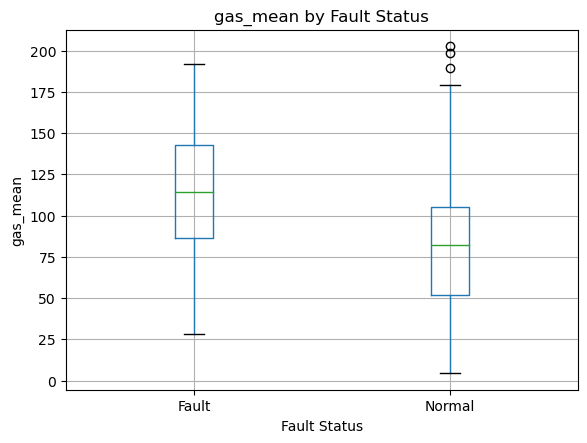

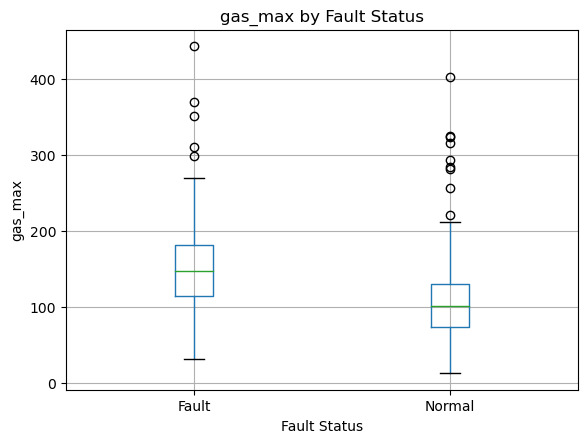

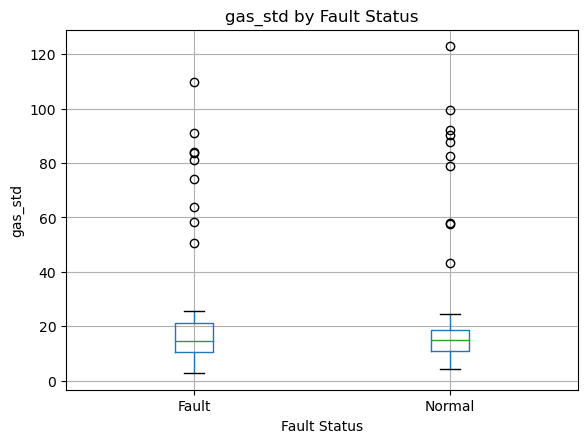

In [51]:
gas_features = [
    "gas_mean",
    "gas_max",
    "gas_std"
]

for col in gas_features:
    
    labeled_data.boxplot(
        column=col,
        by="fault_status"
    )

    plt.title(f"{col} by Fault Status")
    plt.suptitle("")
    plt.xlabel("Fault Status")
    plt.ylabel(col)
    plt.show()

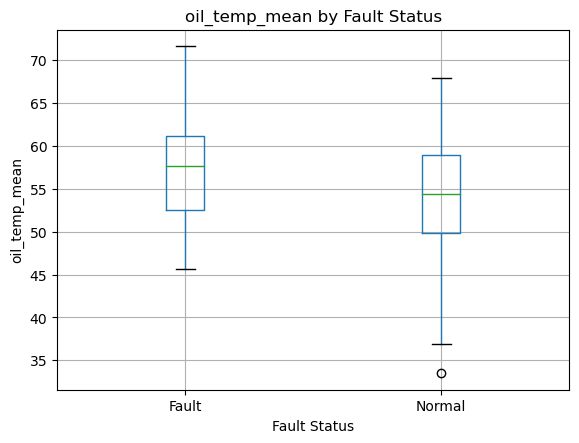

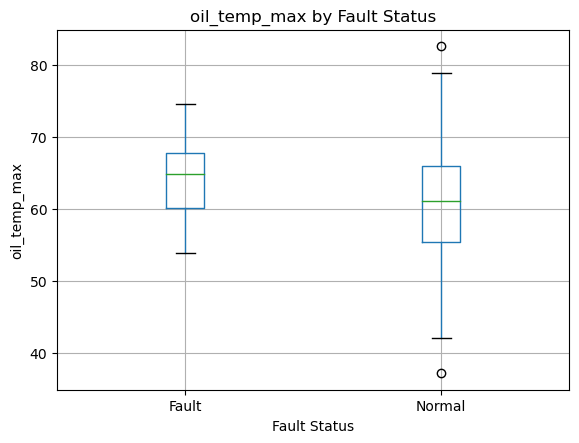

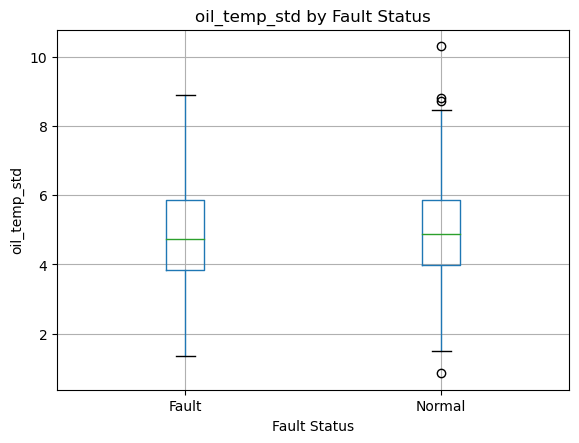

In [52]:
temperature_features = [
    "oil_temp_mean",
    "oil_temp_max",
    "oil_temp_std"
]

for col in temperature_features:
  

    labeled_data.boxplot(
        column=col,
        by="fault_status"
    )

    plt.title(f"{col} by Fault Status")
    plt.suptitle("")
    plt.xlabel("Fault Status")
    plt.ylabel(col)
    plt.show()

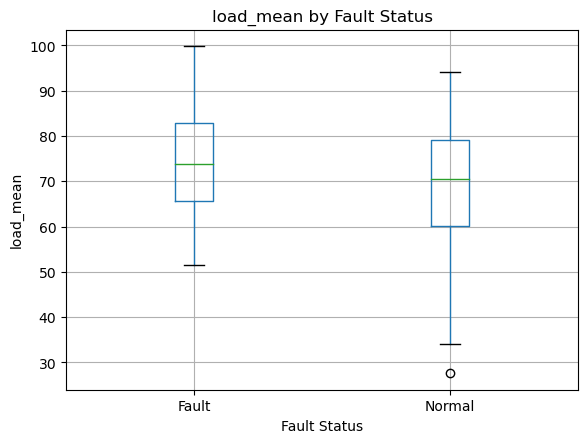

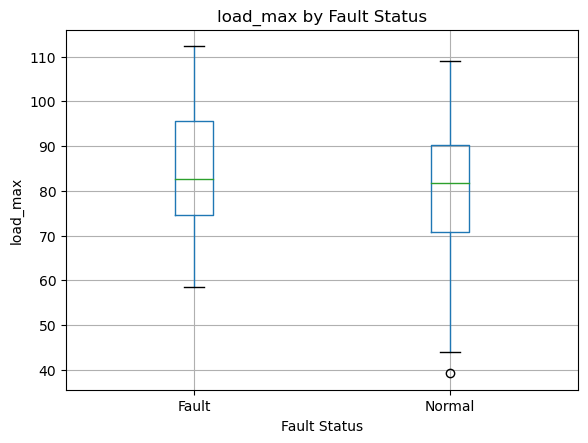

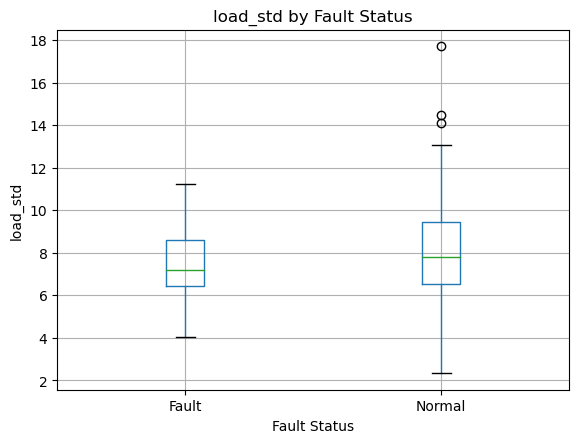

In [53]:
load_features = [
    "load_mean",
    "load_max",
    "load_std"
]

for col in load_features:
    

    labeled_data.boxplot(
        column=col,
        by="fault_status"
    )

    plt.title(f"{col} by Fault Status")
    plt.suptitle("")
    plt.xlabel("Fault Status")
    plt.ylabel(col)
    plt.show()

In [54]:
correlation_matrix = labeled_data[numeric_cols].corr()

correlation_matrix

,install_year,rated_kva,gas_mean,gas_max,gas_std,oil_temp_mean,oil_temp_max,oil_temp_std,load_mean,load_max,load_std
install_year,1.000000,0.054843,0.071487,0.045774,0.050794,-0.099048,-0.133842,-0.052436,-0.083024,-0.063619,-0.048497
rated_kva,0.054843,1.000000,-0.071338,-0.025776,0.019553,0.007854,0.031551,0.069767,0.030441,0.027712,-0.034360
gas_mean,0.071487,-0.071338,1.000000,0.721511,0.203924,-0.022656,-0.065339,-0.087506,-0.048455,-0.051489,-0.047978
gas_max,0.045774,-0.025776,0.721511,1.000000,0.806293,-0.009565,-0.018978,-0.057221,-0.005924,0.010225,-0.007953
gas_std,0.050794,0.019553,0.203924,0.806293,1.000000,-0.012874,-0.003402,-0.023287,0.009509,0.046815,0.052006
oil_temp_mean,-0.099048,0.007854,-0.022656,-0.009565,-0.012874,1.000000,0.918378,0.105085,0.931117,0.869500,-0.018100
oil_temp_max,-0.133842,0.031551,-0.065339,-0.018978,-0.003402,0.918378,1.000000,0.398525,0.847089,0.794486,0.025397
oil_temp_std,-0.052436,0.069767,-0.087506,-0.057221,-0.023287,0.105085,0.398525,1.000000,0.080181,0.084157,0.057704
load_mean,-0.083024,0.030441,-0.048455,-0.005924,0.009509,0.931117,0.847089,0.080181,1.000000,0.948660,0.011653
load_max,-0.063619,0.027712,-0.051489,0.010225,0.046815,0.869500,0.794486,0.084157,0.948660,1.000000,0.255480


## 3.8 EDA Summary

The exploratory analysis identified several differences between Fault and Normal transformers. Fault transformers generally showed higher dissolved gas levels, higher average and maximum oil temperatures, and higher average load.

Among the numerical features, `gas_mean` and `gas_max` showed the clearest separation between Fault and Normal groups. Variability features such as `gas_std`, `oil_temp_std`, and `load_std` showed greater overlap.

The correlation analysis also revealed strong relationships between several temperature and load features, particularly `oil_temp_mean` and `load_mean`, indicating some potential feature redundancy.

These observations will guide the feature engineering and modeling stage, while final feature usefulness will be determined through model evaluation.